In [0]:
#ex_1_cleaning:copy the code from Cascade

import re
sample_thttps://dbc-ce85d634-8982.cloud.databricks.com/editor/notebooks/3454443273050265?o=1466187410014757$0ext = "The 1st film's acting was AMAZING!!! But... the plot? Not so much 😒"   # 1st is added
# Lowercase everything and remove non-letter characters
cleaned_text_1 = re.sub(r'[^a-zA-Z\s]', '', sample_text.lower()) #This pattern keeps only letters (a-z, A-Z) and spaces, removing everything else
cleaned_text_2= re.sub(r'[^A-Za-z0-9\s]', '', sample_text.upper()) # added
print("Cleaned:", cleaned_text_1)
print("Cleaned:", cleaned_text_2)


Cleaned: the st films acting was amazing but the plot not so much 
Cleaned: THE 1ST FILMS ACTING WAS AMAZING BUT THE PLOT NOT SO MUCH 


**Text Preprocessing Steps in NLP**  <br><br>

**1. TOKENIZATION**  <br>
Breaking text into individual words or sentences.  <br><br>

**2. STOPWORD REMOVAL**  <br>
Removing common but low-value words such as *the*, *is*, *and*.  <br><br>

**3. STEMMING / LEMMATIZATION**  <br>
Reducing words to a simpler or standardized form (e.g., *run*, *running*, *ran* → *run*).  <br><br>

**4. CLEANING**  <br>
Removing irrelevant characters such as punctuation, numbers, or extra spaces.  <br>


In [0]:
pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.3/793.3 kB 40.4 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')  # Download only once
nltk.download('punkt_tab') # Download only once

[nltk_data] Downloading package punkt to /home/spark-d91305ce-
[nltk_data]     eb45-4dc9-8ea2-d7/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /home/spark-d91305ce-
[nltk_data]     eb45-4dc9-8ea2-d7/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [0]:
#ex_2_tokenization: copy the code from Cascade
tokens = word_tokenize(cleaned_text)
print("Tokens:", tokens)

Tokens: ['the', 'films', 'acting', 'was', 'amazing', 'but', 'the', 'plot', 'not', 'so', 'much']


In [0]:
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/spark-d91305ce-
[nltk_data]     eb45-4dc9-8ea2-d7/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [0]:
#ex_3_stopword:copy the code from Cascade
stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens if word not in stop_words]
print("Without stopwords:", filtered_tokens)


Without stopwords: ['films', 'acting', 'amazing', 'plot', 'much']


In [0]:
from nltk.stem import PorterStemmer

In [0]:
#ex_3_stemming: copy the code from Cascade
stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]
print("Stemmed:", stemmed_tokens)


Stemmed: ['film', 'act', 'amaz', 'plot', 'much']


In [0]:
pip install spacy

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Upgrade typing_extensions and spaCy
%pip install --upgrade "typing_extensions>=4.12.2" "spacy>=3.7,<3.8"


Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Install the small English model directly (avoids cli download)
%pip install -U "https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.7.1/en_core_web_sm-3.7.1-py3-none-any.whl"

In [0]:
import spacy
spacy.cli.download("en_core_web_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 175.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in an interactive Python session, you may need to exit and restart
Python to load all the package's dependencies. You can exit with Ctrl-D (or
Ctrl-Z and Enter on Windows).



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [0]:
#ex_4_lemmatization:copy the code from Cascade
nlp = spacy.load("en_core_web_sm")
doc = nlp(" ".join(filtered_tokens))
lemmatized_tokens = [token.lemma_ for token in doc]
print("Lemmatized:", lemmatized_tokens)


Lemmatized: ['film', 'act', 'amazing', 'plot', 'much']


In [0]:
#ex_5_application_of_bag_of_words:copy the code from Cascade

from sklearn.feature_extraction.text import CountVectorizer
corpus = [
    "I love this movie, it's fantastic!",
    "This movie was awful and was boring.",
    "Fantastic visuals but weak storyline.",
    "I wouldn’t recommend this film."
]

vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(corpus)

print("Vocabulary:", vectorizer.get_feature_names_out())
print("BoW Contents:\n", X_bow)
print("BoW Matrix:\n", X_bow.toarray())


Vocabulary: ['and' 'awful' 'boring' 'but' 'fantastic' 'film' 'it' 'love' 'movie'
 'recommend' 'storyline' 'this' 'visuals' 'was' 'weak' 'wouldn']
BoW Contents:
   (0, 7)	1
  (0, 11)	1
  (0, 8)	1
  (0, 6)	1
  (0, 4)	1
  (1, 11)	1
  (1, 8)	1
  (1, 13)	2
  (1, 1)	1
  (1, 0)	1
  (1, 2)	1
  (2, 4)	1
  (2, 12)	1
  (2, 3)	1
  (2, 14)	1
  (2, 10)	1
  (3, 11)	1
  (3, 15)	1
  (3, 9)	1
  (3, 5)	1
BoW Matrix:
 [[0 0 0 0 1 0 1 1 1 0 0 1 0 0 0 0]
 [1 1 1 0 0 0 0 0 1 0 0 1 0 2 0 0]
 [0 0 0 1 1 0 0 0 0 0 1 0 1 0 1 0]
 [0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1]]


In [0]:
#ex_5_application_of_TF-IDF(Term Frequency–Inverse Document Frequency):copy the code from Cascade
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(corpus)

print("Vocabulary:", tfidf.get_feature_names_out())
print("TF-IDF Matrix:\n", X_tfidf.toarray())


Vocabulary: ['and' 'awful' 'boring' 'but' 'fantastic' 'film' 'it' 'love' 'movie'
 'recommend' 'storyline' 'this' 'visuals' 'was' 'weak' 'wouldn']
TF-IDF Matrix:
 [[0.         0.         0.         0.         0.41263976 0.
  0.52338122 0.52338122 0.41263976 0.         0.         0.33406745
  0.         0.         0.         0.        ]
 [0.35291425 0.35291425 0.35291425 0.         0.         0.
  0.         0.         0.27824164 0.         0.         0.22526059
  0.         0.70582849 0.         0.        ]
 [0.         0.         0.         0.46516193 0.36673901 0.
  0.         0.         0.         0.         0.46516193 0.
  0.46516193 0.         0.46516193 0.        ]
 [0.         0.         0.         0.         0.         0.5417361
  0.         0.         0.         0.5417361  0.         0.34578314
  0.         0.         0.         0.5417361 ]]


**EXAMPL: How TF-IDF is calcualted** <br>

Step 1: Term Frequency (TF)
TF measures how often a term appears in a document: <br>
TF(t, d) = (Number of times term t appears in document d) / (Total number of terms in document d)

Example:
Document: 'I love NLP and I love Python'
The word 'love' appears 2 times out of 6 total words.
TF(love) = 2 / 6 = 0.333      <br> <br>
Step 2: Inverse Document Frequency (IDF)
IDF measures how unique or rare a word is across all documents in a corpus:
IDF(t) = log(N / (1 + n_t))

Where:
- N = Total number of documents
- n_t = Number of documents containing term t

Example:
If we have 5 documents and 'love' appears in 3 of them:
IDF(love) = log(5 / (1 + 3)) = log(1.25) = 0.22 <br>

Step 3: Combining TF and IDF
The TF-IDF score is obtained by multiplying TF and IDF:
TF-IDF(t, d) = TF(t, d) × IDF(t)

Continuing the previous example:
TF-IDF(love) = 0.333 × 0.22 = 0.073


High TF-IDF	----> Word is frequent in a specific document but rare across the corpus → important or unique <br>
Low TF-IDF  ----> Word appears in most documents → not distinctive

In [0]:

# installing the en_core_web_md model
%pip install -U "https://github.com/explosion/spacy-models/releases/download/en_core_web_md-3.7.1/en_core_web_md-3.7.1-py3-none-any.whl"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 121.4 MB/s eta 0:00:00
  Using cached spacy-3.7.5-cp311-cp311-manylinux_2_17_aarch64.manylinux2014_aarch64.whl.metadata (27 kB)
  Using cached thinc-8.2.5-cp311-cp311-manylinux_2_17_aarch64.manylinux2014_aarch64.whl.metadata (15 kB)
  Using cached blis-0.7.11-cp311-cp311-manylinux_2_17_aarch64.manylinux2014_aarch64.whl.metadata (7.4 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_aarch64.manylinux2014_aarch64.whl.metadata (62 kB)
Using cached spacy-3.7.5-cp311-cp311-manylinux_2_17_aarch64.manylinux2014_aarch64.whl (6.2 MB)
Using cached thinc-8.2.5-cp311-cp311-manylinux_2_17_aarch64.manylinux2014_aarch64.whl (868 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_aarch64.manylinux2014_aarch64.whl (14.2 MB)
Using cached blis-0.7.11-cp311-cp311-manylinux_2_17_aarch64.manylinux2014_aarch64.whl (1.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.4
    Uninstalling numpy-2.3.4:
      Succ

In [0]:
pip install -U spacy

In [0]:
#ex_6_application_of_word_emmbeddings:copy the code from Cascade
import spacy
# Load medium English model with word vectors
nlp = spacy.load("en_core_web_md")  # Run: python -m spacy download en_core_web_md

# Compare word similarity
words = ["king", "queen", "cat", "dog", "car", "banana"]

for w1 in words:
    for w2 in words:
        if w1 != w2:
            similarity_md = nlp(w1).similarity(nlp(w2))
            print(f"{w1} ↔ {w2}: {similarity_md:.2f}")


king ↔ queen: 0.61
king ↔ cat: 0.09
king ↔ dog: 0.13
king ↔ car: 0.07
king ↔ banana: 0.08
queen ↔ king: 0.61
queen ↔ cat: 0.25
queen ↔ dog: 0.17
queen ↔ car: 0.04
queen ↔ banana: 0.09
cat ↔ king: 0.09
cat ↔ queen: 0.25
cat ↔ dog: 0.82
cat ↔ car: 0.20
cat ↔ banana: 0.22
dog ↔ king: 0.13
dog ↔ queen: 0.17
dog ↔ cat: 0.82
dog ↔ car: 0.33
dog ↔ banana: 0.21
car ↔ king: 0.07
car ↔ queen: 0.04
car ↔ cat: 0.20
car ↔ dog: 0.33
car ↔ banana: 0.11
banana ↔ king: 0.08
banana ↔ queen: 0.09
banana ↔ cat: 0.22
banana ↔ dog: 0.21
banana ↔ car: 0.11


**We used en_core_web_md model, are there small and large models? Yes** <br>
**English Models in spaCy**  <br>

|       Model      |            Size               |                 Best For 
|------------------|-------------------------------|--------------------------------------------------------------------------|
| `en_core_web_sm` | Small (~12 MB)                | Fast prototyping, limited memory environments                            |
| `en_core_web_md` | Medium (~120 MB)              | General NLP tasks, semantic similarity                                   |
| `en_core_web_lg` | Large (~800 MB)               | Highest accuracy for English, semantic similarity, context-rich analysis |


**Uisng another text data, let's try these four different models in decising about the similarity between two texts** <br>
**We need to install the rest of the models**

In [0]:
#Install English models for spaCy

%pip install -U "https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.7.1/en_core_web_sm-3.7.1-py3-none-any.whl" 
%pip install -U "https://github.com/explosion/spacy-models/releases/download/en_core_web_lg-3.7.1/en_core_web_lg-3.7.1-py3-none-any.whl"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 151.8 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.7/587.7 MB 125.6 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
#not in cascade
import spacy
import pandas as pd

# Choose which models to try (only those installed will run)
MODELS = ["en_core_web_sm", "en_core_web_md", "en_core_web_lg"]

# Two texts to compare
text_a = ("I love ML and ADA courses, while I don't like going out with friends")
text_b = ("The ML and ADA courses are good experience for me, while hangging out with friends is not nice")

# Load available models
nlps = {}
for name in MODELS:
        nlps[name] = spacy.load(name)
   
# Compute similarity for each available model
rows = []
for name, nlp in nlps.items():
    doc1 = nlp(text_a)
    doc2 = nlp(text_b)
    rows.append({"model": name, "similarity": round(float(doc1.similarity(doc2)), 4)})

# Show a tiny table
similarity_df = pd.DataFrame(rows).set_index("model").sort_index()
print(similarity_df)


                similarity
model                     
en_core_web_lg      0.7436
en_core_web_md      0.7709
en_core_web_sm      0.6308


/home/spark-4b9dfb1e-2390-4768-ab9f-34/.ipykernel/21653/command-7959493329181187-2769447925:22: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Doc.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors, or use one of the larger models instead if available.
  rows.append({"model": name, "similarity": round(float(doc1.similarity(doc2)), 4)})


**_Choosing the Right Approach between BoW, TF-IDF, and Embeddings<br>_**

Bag of Words (BoW)  <br>
Best for: Quick baselines, small datasets.  <br>
  Strengths: Simple, fast, interpretable.  <br>
  Weaknesses: Ignores meaning and context.  

---

TF-IDF (Term Frequency–Inverse Document Frequency)  <br>
Best for: Classification, document filtering.  <br>
  Strengths: Weighs rare terms, reduces noise.  <br>
  Weaknesses: Still lacks word semantics.  

---

Embeddings (Word2Vec, GloVe, BERT, etc.)  <br>
Best for: Semantic tasks, similarity, LLM foundations.  <br>
  Strengths: Captures meaning, enables context.  <br>
  Weaknesses: Requires pre-trained models, less interpretable.  



---
**Application** <br>
---
- Now, we will build an ML predictive model for NLP application.  <br>
- The goal is to classify text based on its content, e.g., predicting **sentiment** (positive or negative).  <br>
- This section covers:  <br>
  - Building a sentiment classification model.  <br>
  - Evaluating and interpreting model performance.  <br>
  - Optionally applying word embeddings for semantic understanding.  <br>
- **Task Overview: Sentiment Classification**  <br>
  - Objective: Predict whether a given review expresses a positive or negative tone.  <br>
  - Dataset: `movie_reviews` from NLTK (2,000 labeled reviews: *pos* or *neg*).  <br>
  - Task Type: Binary text classification.  


**1- Dataset preparation**


In [0]:
#copy the code from Cascade
import nltk
from nltk.corpus import movie_reviews
import random

nltk.download('movie_reviews')

# Load and shuffle data
fileids = movie_reviews.fileids()
random.shuffle(fileids)

# Extract text and labels
texts = [movie_reviews.raw(fileid) for fileid in fileids]
labels = [1 if fileid.startswith('pos') else 0 for fileid in fileids]


[nltk_data] Downloading package movie_reviews to
[nltk_data]     /home/spark-d1b2a769-783c-417e-b0c7-7e/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


**2- Splitting the dataset into training and test sets**

In [0]:
#copy the code from Cascade
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

**3- Data exploarion and visulization** <br>
Word cloud helps highlight which words occur most often in positive vs. negative reviews to see what kinds of words dominate each class.


In [0]:
pip install wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.6/27.6 MB 68.1 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for wordcloud: filename=wordcloud-1.9.4-cp311-cp311-linux_aarch64.whl size=400835 sha256=78b3fd29044d34fa1326be10debc25053d6d712bebe7a9e017309de3ae17633d
  Stored in directory: /home/spark-d1b2a769-783c-417e-b0c7-7e/.cache/pip/wheels/1d/46/40/0e8bd59213d60c488378ff39099cc45cb114bcb6f8cdd84232
Successfully built wordcloud
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


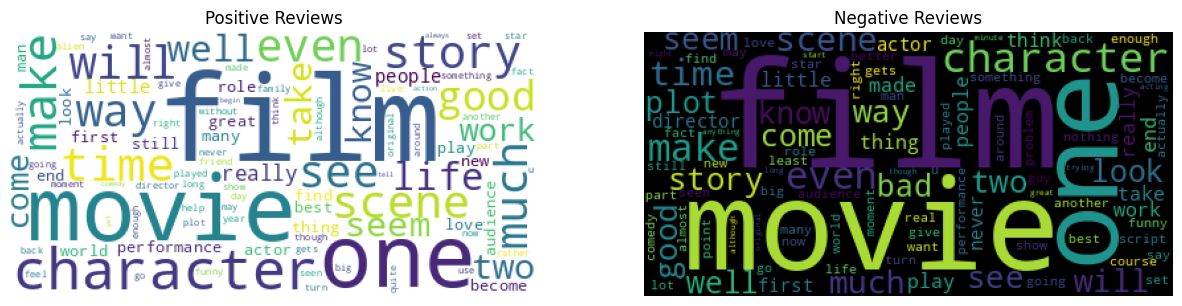

In [0]:
#copy the code from Cascade
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all positive and negative reviews
pos_reviews = ' '.join([texts[i] for i in range(len(texts)) if labels[i] == 1])
neg_reviews = ' '.join([texts[i] for i in range(len(texts)) if labels[i] == 0])
# Generate word clouds
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
axs[0].imshow(WordCloud(background_color='white', max_words=100).generate(pos_reviews))
axs[0].set_title('Positive Reviews')
axs[0].axis('off')

axs[1].imshow(WordCloud(background_color='black', max_words=100).generate(neg_reviews))
axs[1].set_title('Negative Reviews')
axs[1].axis('off')
plt.show()

**4- Establish the pipeline**<br>
**Model Pipeline: TF-IDF + Logistic Regression** <br>
Now we’ll build a machine learning pipeline using scikit-learn. It handles: <br>
•	Vectorization using TfidfVectorizer. <br>
•	Classification using LogisticRegression.


In [0]:
#copy the code from Cascade
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Build pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000))
])


**5- Train the model**

In [0]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('clf', LogisticRegression(max_iter=1000))])

6- Making Predictions and Evaluating the Model


In [0]:
#copy the code from Cascade
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
y_pred = pipeline.predict(X_test)

# Basic metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.785

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.80      0.77       185
           1       0.82      0.77      0.79       215

    accuracy                           0.79       400
   macro avg       0.78      0.79      0.78       400
weighted avg       0.79      0.79      0.79       400



**Classification Report Metrics Explained**  <br>

**Precision:**  <br>
Measures how many of the predicted positives were actually correct.  <br>
High precision = few false positives.  <br>
Precision = TP / (TP + FP)  <br>

**Recall (Sensitivity):**  <br>
Measures how many of the actual positives were correctly identified.  <br>
High recall = few false negatives.  <br>
Recall = TP / (TP + FN)  <br>

**F1-Score:**  <br>
The harmonic mean of Precision and Recall.  <br>
Balances both metrics, especially useful for imbalanced datasets.  <br>
F1 = 2 × (Precision × Recall) / (Precision + Recall)  <br>

**Support:**  <br>
The number of true instances for each class in the dataset.  <br>
Shows how many samples belong to each class (e.g., positive or negative).  <br>

**Accuracy:**  <br>
Overall proportion of correctly classified samples.  <br>
Accuracy = (TP + TN) / (TP + TN + FP + FN)  <br>

**Macro Average:**  <br>
Average of Precision, Recall, and F1-score for all classes, giving equal weight to each class.  <br>
Macro Avg = (Metric_class1 + Metric_class2 + ... + Metric_classN) / N  <br>

**Weighted Average:**  <br>
Average of Precision, Recall, and F1-score weighted by the number of samples (Support) per class.  <br>
Weighted Avg = Σ(Metric_class × Support_class) / Σ(Support)  <br>


**7- Visualizing the Confusion Matrix**

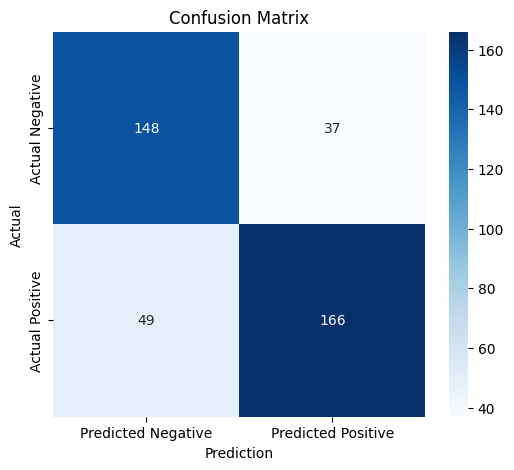

In [0]:
#copy the code from Cascade
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"])
plt.title("Confusion Matrix")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.show()


**Verification Task:**
**Uisng the numbers shown in the matrix above calculate mannually the Precision and the Recall.**

**Task: Construct two other different configurations of the pipeline and comapre the results**

In [0]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import SGDClassifier, LogisticRegression, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np

# EXAMPLES assume X (list/Series of texts) and y (labels) already exist

pipelines = {
    # 1) Count BoW + Linear SVM
    "bow_nb": Pipeline([
        ("vect", CountVectorizer(stop_words="english")),
        ("clf", LinearSVC())
    ]),

    # 2) TF-IDF + Calibrated Linear SVM (adds calibrated probabilities)
    "tfidf_calibrated_svc": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english")),
        ("clf", CalibratedClassifierCV(LinearSVC(), cv=5))
    ])
}


# === Quick evaluation harness (5-fold CV accuracy) ===
def compare(pipes, X, y):
    results = []
    for name, pipe in pipes.items():
        try:
            scores = cross_val_score(pipe, X, y, cv=5, n_jobs=-1)
            results.append((name, scores.mean(), scores.std()))
        except Exception as e:
            results.append((name, f"ERROR: {e}", ""))
    return sorted(results, key=lambda r: (r[1] if isinstance(r[1], float) else -1), reverse=True)

# Example usage:
# leaderboard = compare(pipelines, X, y)
# for name, mean_acc, std_acc in leaderboard:
#     print(f"{name:22s}  acc={mean_acc} (+/- {std_acc})")
